In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import sqlite3

## Collecte de l'historique boursier

In [2]:

# Définition des tickers identifiés comme pioniers de la souvainneté alimentaire Européenne 
tickers = {
    "Yara (Norvège)": "YAR.OL",
    "OCI (Pays-Bas)": "OCI.AS",
    "ICL (Israël)": "ICL",
    "CF Industries (USA/UK)": "CF",
    "Grupa Azoty (Pologne)": "ATT.WA",
    "K+S (Allemagne)": "SDF.DE"
}

# Extraction des prix de clôture pour les 2 dernières années
# On utilise la liste des valeurs du dictionnaire tickers.values()
df_prices = yf.download(list(tickers.values()), start="2022-01-01", interval="1d")['Close']

# On renomme les colonnes pour que ce soit plus lisible que les symboles boursiers
# On inverse le dictionnaire tickers pour faire la correspondance
inv_tickers = {v: k for k, v in tickers.items()}
df_prices.rename(columns=inv_tickers, inplace=True)

# Affichage des premières lignes pour vérifier que tout fonctionne
print("Données récupérées avec succès !")
display(df_prices.head())

[*********************100%***********************]  6 of 6 completed

Données récupérées avec succès !


Ticker,Grupa Azoty (Pologne),CF Industries (USA/UK),ICL (Israël),OCI (Pays-Bas),K+S (Allemagne),Yara (Norvège)
Date,,,,,,
2022-01-03,34.000000,64.455750,7.861814,2.402371,13.323296,354.200714
2022-01-04,34.360001,64.948822,7.982271,2.441020,13.848286,350.416504
2022-01-05,34.500000,62.976536,7.958179,2.512216,14.227692,360.709503
2022-01-06,NaN,63.223064,8.391822,2.410507,14.112987,341.788574
2022-01-07,34.000000,63.131763,8.367732,2.445088,14.329159,344.815918


In [3]:
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1105 entries, 2022-01-03 to 2026-04-14
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Grupa Azoty (Pologne)   1069 non-null   float64
 1   CF Industries (USA/UK)  1072 non-null   float64
 2   ICL (Israël)            1072 non-null   float64
 3   OCI (Pays-Bas)          1094 non-null   float64
 4   K+S (Allemagne)         1090 non-null   float64
 5   Yara (Norvège)          1074 non-null   float64
dtypes: float64(6)
memory usage: 60.4 KB


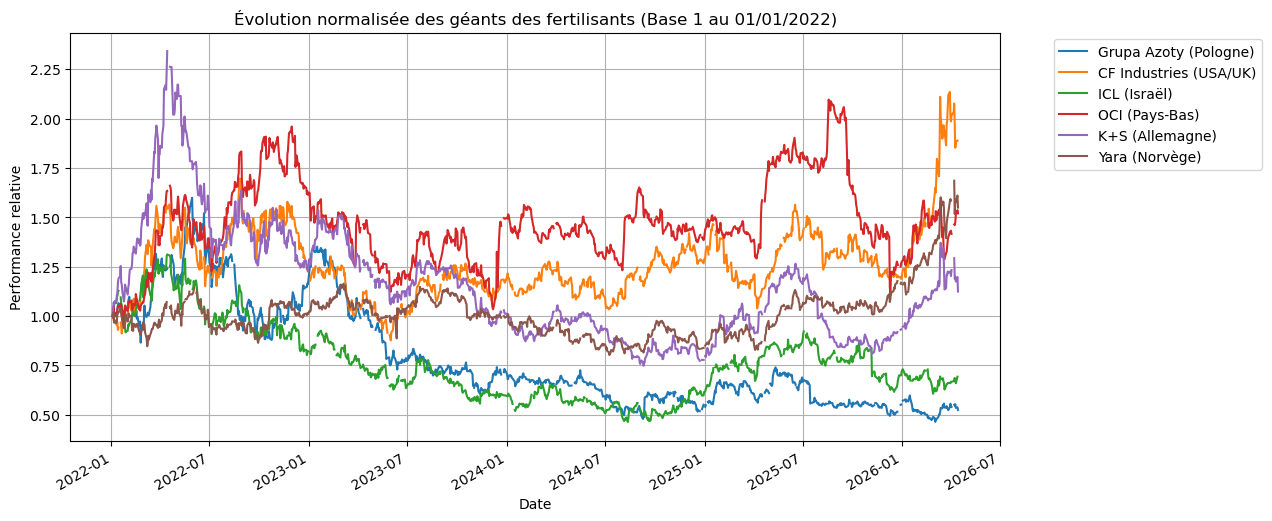

In [4]:
# On normalise les prix pour pouvoir comparer des actions qui valent 10€ et d'autres 100€
# On divise chaque valeur par son prix de départ (la première ligne)
data_normalized = df_prices / df_prices.iloc[0]

data_normalized.plot(figsize=(12, 6))
plt.title("Évolution normalisée des géants des fertilisants (Base 1 au 01/01/2022)")
plt.ylabel("Performance relative")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## Collecte des données d'actualité

In [5]:
# La clé secrète NewsAPI
API_KEY = "5b7edee298df4374b80fa69f3c032e18"

# Notre requête stratégique : Engrais/Agriculture ET Europe/Gaz/Moyen-Orient
query = '("fertilizer" OR "agriculture") AND ("Europe" OR "gas" OR "Middle East" OR "Iran")'

# On interroge l'API (recherche sur les 30 derniers jours par défaut, trié par pertinence)
url = f"https://newsapi.org/v2/everything?q={query}&language=en&sortBy=relevancy&apiKey={API_KEY}"

response = requests.get(url)
data = response.json()

# Si la requête fonctionne, on transforme le résultat en tableau propre
if data['status'] == 'ok':
    articles = data['articles']
    # On ne garde que les colonnes qui nous intéressent pour le NLP plus tard
    df_news = pd.DataFrame(articles)[['publishedAt', 'title', 'description', 'source']]
    
    # On extrait juste le nom de la source pour que ce soit plus propre
    df_news['source'] = df_news['source'].apply(lambda x: x['name'])
    
    print(f"Succès ! {len(df_news)} articles récupérés.")
    display(df_news.head())
else:
    print("Erreur lors de la récupération :", data.get('message'))

Succès ! 94 articles récupérés.


,publishedAt,title,description,source
0,2026-04-13T12:11:04Z,The Strait of Hormuz blockade is causing a slo...,"Farmers are very busy in the spring, under pre...",The Verge
1,2026-03-19T19:30:17Z,Higher Oil Prices From Trump’s Iran War Risk K...,President Deals seems to be setting the global...,Gizmodo.com
2,2026-03-17T18:40:09Z,Trump Advisor Says Pain for U.S. Consumers ‘La...,Kevin Hassett claims the war will last 4-6 weeks.,Gizmodo.com
3,2026-03-19T15:29:04Z,What smart people are saying about oil's lates...,After Brent crude surged 11% to levels last se...,Business Insider
4,2026-03-25T09:38:39Z,"U.S. drafts plan to end war with Iran as 2,000...","Nearly a month into the war with Iran, the Tru...",NPR


In [6]:
# Téléchargement du dictionnaire d'analyse (une seule fois suffit)
nltk.download('vader_lexicon')

# Initialisation de notre "juge" de sentiment
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\brunochazeaud\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [7]:
# Fonction simple pour analyser un texte et retourner le score global
def calculer_sentiment(texte):
    if pd.isna(texte): # Sécurité au cas où un titre est vide
        return 0
    # On calcule les scores et on ne garde que le "compound"
    return sia.polarity_scores(str(texte))['compound']

# On applique cette fonction à notre colonne 'title'
# et on stocke le résultat dans une nouvelle colonne
df_news['score_sentiment'] = df_news['title'].apply(calculer_sentiment)

# On va jeter un oeil aux résultats extrêmes pour vérifier si le modèle a du bon sens !
print("--- TOP 3 ARTICLES POSITIFS ---")
display(df_news.nlargest(3, 'score_sentiment')[['title', 'score_sentiment']])

print("\n--- TOP 3 ARTICLES NÉGATIFS (Crises) ---")
display(df_news.nsmallest(3, 'score_sentiment')[['title', 'score_sentiment']])

--- TOP 3 ARTICLES POSITIFS ---


,title,score_sentiment
92,Africa’s richest man offers fuel relief,0.7579
41,A surprise resignation could open the door for...,0.5719
66,The Bee That Everyone Wants to Save,0.4939



--- TOP 3 ARTICLES NÉGATIFS (Crises) ---


,title,score_sentiment
83,Spring planting in crisis as Middle East war d...,-0.9118
1,Higher Oil Prices From Trump’s Iran War Risk K...,-0.8860
55,Sad! The War in Iran Is So Bad That the U.S. C...,-0.8775


## Sauvegarde en base SQL

In [9]:
# 1. Création de la base de données locale
# Cela va créer un fichier 'agri_data.db' dans le même dossier que le Notebook
conn = sqlite3.connect('agri_data.db')

# 2. Sauvegarde du tableau des prix
# On nomme la table 'stock_prices'. if_exists='replace' permet d'écraser la table si on relance la cellule.
df_prices.to_sql('stock_prices', conn, if_exists='replace')

# 3. Sauvegarde du tableau des actualités et de leurs scores de sentiment
# On nomme la table 'news_sentiment'.
df_news.to_sql('news_sentiment', conn, if_exists='replace', index=False)

# 4. On ferme la porte de la base de données proprement
conn.close()

print("Succès ! La base de données 'agri_data.db' a été créée et remplie.")

Succès ! La base de données 'agri_data.db' a été créée et remplie.


In [10]:
# On rouvre la connexion
conn = sqlite3.connect('agri_data.db')

# On écrit une requête SQL basique pour lire la table des sentiments
test_lecture = pd.read_sql("SELECT * FROM news_sentiment LIMIT 2", conn)

conn.close()

print("Lecture depuis la base de données réussie :")
display(test_lecture)

Lecture depuis la base de données réussie :


,publishedAt,title,description,source,score_sentiment
0,2026-04-13T12:11:04Z,The Strait of Hormuz blockade is causing a slo...,"Farmers are very busy in the spring, under pre...",The Verge,-0.6249
1,2026-03-19T19:30:17Z,Higher Oil Prices From Trump’s Iran War Risk K...,President Deals seems to be setting the global...,Gizmodo.com,-0.8860


In [ ]:
##